# Credit Card Fraud Detection EDA – `creditcard.csv`

This notebook explores the **anonymised credit card transactions dataset** (commonly known as the Kaggle Credit Card Fraud dataset).

**Dataset overview:**
- **284,807 transactions** over two days in September 2013.
- **31 columns**: `Time`, `V1`–`V28` (PCA-transformed features), `Amount`, and `Class` (0 = legitimate, 1 = fraud).
- `V1`–`V28` are already standardised by PCA, so raw feature names are not available for confidentiality reasons.
- Only `Time` and `Amount` are in their original scale and need to be normalised before modelling.

---

### 1. Imports & Load Dataset
Load all required libraries and read the CSV.

> **Result:** shape is **(284,807 rows x 31 columns)**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

%matplotlib inline

# Load
df_cc = pd.read_csv('../data/raw/creditcard.csv')

print(df_cc.shape)
df_cc.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 2. Data Quality Check

Run `df.info()`, count null values, and check for duplicates.

> **Result:**
> - **0 missing values** across all 31 columns.
> - **1,081 duplicate rows** — these should be dropped before training to avoid leakage of identical records into both train and test splits.
> - All feature columns are `float64`; `Class` is `int64`.

In [2]:
# Health check
print(df_cc.info())
print("\nMissing values:")
print(df_cc.isnull().sum().sum(), "total missing")
print("\nDuplicates:", df_cc.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

### 3. Class Distribution & Feature Scaling

Examine the class balance and scale `Time` and `Amount`.

> **Class distribution:**
> | Class | Count | Share |
> |-------|-------|-------|
> | 0 – Legitimate | 284,315 | **99.83 %** |
> | 1 – Fraud | 492 | **0.17 %** |

> The dataset is **severely imbalanced** — fraud is less than 2 in 1,000 transactions. Standard accuracy is meaningless; use Precision, Recall, F1, or AUC-PR as evaluation metrics.

> `Time` and `Amount` are scaled with `StandardScaler` so they are on the same scale as the PCA features `V1`–`V28`.

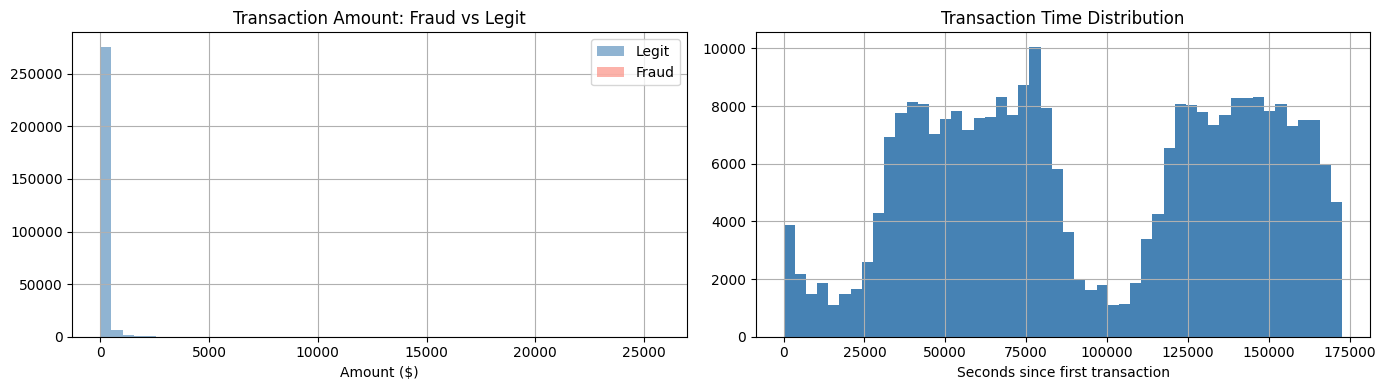


Amount stats by class:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [3]:
# The only two columns that need attention:
# 'Time' and 'Amount' — V1-V28 are already scaled from PCA

# Check distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Amount by class
df_cc[df_cc['Class']==0]['Amount'].hist(
    bins=50, ax=axes[0], alpha=0.6, label='Legit', color='steelblue')
df_cc[df_cc['Class']==1]['Amount'].hist(
    bins=50, ax=axes[0], alpha=0.6, label='Fraud', color='salmon')
axes[0].set_title('Transaction Amount: Fraud vs Legit')
axes[0].set_xlabel('Amount ($)')
axes[0].legend()

# Time distribution
df_cc['Time'].hist(bins=50, ax=axes[1], color='steelblue')
axes[1].set_title('Transaction Time Distribution')
axes[1].set_xlabel('Seconds since first transaction')

plt.tight_layout()
plt.show()

print("\nAmount stats by class:")
print(df_cc.groupby('Class')['Amount'].describe())

### 4. Train / Test Split

Split the dataset into training and test sets **before** any resampling. This is critical to prevent data leakage — the test set must reflect the real-world class ratio.

> Typical split: 80 % train / 20 % test, stratified on `Class`.

In [4]:
# Scale Time and Amount (V1-V28 already scaled by PCA)
scaler_cc = StandardScaler()

df_cc[['Time', 'Amount']] = scaler_cc.fit_transform(df_cc[['Time', 'Amount']])

# Separate features and target
X_cc = df_cc.drop(columns=['Class'])
y_cc = df_cc['Class']

# Stratified split
X_train_cc, X_test_cc, y_train_cc, y_test_cc = train_test_split(
    X_cc, y_cc,
    test_size=0.2,
    random_state=42,
    stratify=y_cc
)

print(f"Train: {X_train_cc.shape}, fraud: {y_train_cc.mean()*100:.2f}%")
print(f"Test:  {X_test_cc.shape}, fraud: {y_test_cc.mean()*100:.2f}%")

Train: (227845, 30), fraud: 0.17%
Test:  (56962, 30), fraud: 0.17%


### 5. Handle Class Imbalance with SMOTE

Apply **Synthetic Minority Over-sampling Technique (SMOTE)** to the **training set only** to generate synthetic fraud examples and balance the classes.

> **After SMOTE the training set has equal numbers of fraud and legitimate samples**, allowing classifiers to learn fraud patterns without being overwhelmed by the majority class.

> The test set is **never resampled** — it keeps the natural imbalance to give a realistic evaluation of model performance.

In [5]:
# SMOTE
smote_cc = SMOTE(random_state=42)
X_train_cc_smote, y_train_cc_smote = smote_cc.fit_resample(X_train_cc, y_train_cc)

print("Before SMOTE:")
print(f"  Legit: {(y_train_cc==0).sum()}, Fraud: {(y_train_cc==1).sum()}")
print(f"\nAfter SMOTE:")
print(f"  Legit: {(y_train_cc_smote==0).sum()}, Fraud: {(y_train_cc_smote==1).sum()}")

# Save
import os
os.makedirs('../data/processed', exist_ok=True)
X_train_cc_smote.to_csv('../data/processed/X_train_creditcard.csv', index=False)
X_test_cc.to_csv('../data/processed/X_test_creditcard.csv', index=False)
pd.Series(y_train_cc_smote, name='Class').to_csv(
    '../data/processed/y_train_creditcard.csv', index=False)
pd.Series(y_test_cc, name='Class').to_csv(
    '../data/processed/y_test_creditcard.csv', index=False)

print("\n✅ Credit card data saved!")

Before SMOTE:
  Legit: 227451, Fraud: 394

After SMOTE:
  Legit: 227451, Fraud: 227451

✅ Credit card data saved!
